# Phase 5: Hyperparameter Sensitivity & Ablation

## Objective
Understand which hyperparameters have the biggest impact on Q-Learning's performance,
identify critical thresholds, and characterise the robustness of the winning method.

## Method: Q-Learning
Q-Learning was chosen as the base method from Phase 4: it achieved the highest
success rate (85.3% ± 4.3%) with the lowest seed variance among all tabular methods.
Its off-policy update rule — bootstrapping from `max_a Q(s', a)` regardless of the
exploratory action — makes it inherently more robust to seed-dependent exploration paths
than SARSA. Profiling the winning method gives the most actionable sensitivity estimates
for understanding the learning problem.

## Experimental Design

### One-Factor-At-a-Time (OFAT)
We vary one hyperparameter at a time while holding all others fixed at the baseline
configuration. This isolates each parameter's individual effect on final performance.

**Baseline configuration** (from Phase 4 default):

| Parameter | Baseline value |
|-----------|---------------|
| α (learning rate) | 0.1 |
| γ (discount factor) | 0.99 |
| ε_decay | 0.995 |
| ε_start | 1.0 |
| ε_min | 0.05 |

**Parameters swept:**

| Parameter | Values tested |
|-----------|--------------|
| α | {0.01, 0.05, **0.1**, 0.2, 0.5} |
| γ | {0.90, 0.95, **0.99**, 0.999} |
| ε_decay | {0.990, 0.995, **0.995**, 0.999, 0.9995} |
| ε_start | {0.25, 0.50, 0.75, **1.0**} |
| ε_min | {0.01, **0.05**, 0.10, 0.20} |

### Interaction Effects
A 2D grid over (α, γ) reveals whether the two most fundamental parameters
interact — i.e. whether the optimal α depends on γ or vice versa.

### Settings
- Seeds: 5 per configuration
- Episodes: 5 000 per seed (same budget as Phase 4)
- Primary metric: mean success rate over the last 200 episodes
- Secondary metric: episodes to first 10% rolling SR (convergence speed)


## Setup

In [23]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import product as iterproduct

root_path = os.path.abspath("..")
if root_path not in sys.path:
    sys.path.append(root_path)

from src.environment_utils import create_env
from src.agents.tabular_agents import QLearning
from src.evaluation import train_agent, _extract_training_lists

BASE = dict(alpha=0.1, gamma=0.99, epsilon_decay=0.995,
            epsilon_start=1.0, epsilon_min=0.05)

N_BINS     = 20
N_SEEDS    = 5
N_EPISODES = 5_000

OFAT_COLOR  = "#2E86AB"
SHADE_COLOR = "#A8D8EA"


def run_qlearning(alpha, gamma, epsilon_decay, epsilon_start, epsilon_min,
                  n_episodes=N_EPISODES, n_seeds=N_SEEDS):
    """
    Train Q-Learning with given hyperparams over n_seeds.
    Returns (per-seed SR array, per-seed convergence episode array).
    SR = mean success rate over last 200 episodes.
    Convergence = first episode where rolling-100 SR >= 10% (N_EPISODES if never).
    """
    seed_srs   = []
    seed_conv  = []
    for seed in range(n_seeds):
        env   = create_env("discrete", "min_steps", seed=seed)
        agent = QLearning(
            n_pos_bins=N_BINS, n_vel_bins=N_BINS,
            alpha=alpha, gamma=gamma,
            epsilon_start=epsilon_start,
            epsilon_decay=epsilon_decay,
            epsilon_min=epsilon_min,
        )
        m, _ = train_agent(agent, env, n_episodes=n_episodes, seed=seed, verbose=False)
        _, succs, _ = _extract_training_lists(m)
        env.close()
        seed_srs.append(np.mean(succs[-200:]) * 100)
        # Convergence speed: first episode with rolling-100 SR >= 10%
        ma  = np.convolve(np.asarray(succs, float), np.ones(100) / 100, "valid")
        idx = np.argmax(ma >= 0.10)
        seed_conv.append(int(idx + 100) if ma[idx] >= 0.10 else n_episodes)
    return np.array(seed_srs), np.array(seed_conv)


print("✓ Setup complete  |  Base config:", BASE)
print(f"Bins: {N_BINS}×{N_BINS}  |  Episodes: {N_EPISODES}  |  Seeds: {N_SEEDS}")


✓ Setup complete  |  Base config: {'alpha': 0.1, 'gamma': 0.99, 'epsilon_decay': 0.995, 'epsilon_start': 1.0, 'epsilon_min': 0.05}
Bins: 20×20  |  Episodes: 5000  |  Seeds: 5


## Section 1 — Learning Rate α

α controls how strongly each new transition overwrites the existing Q-value estimate.

- **Too small (α=0.01)**: Q-values converge extremely slowly. The effective averaging
  horizon is α⁻¹ = 100 transitions; early −200 episode returns will anchor Q(s,a) near
  −200 for a very long time before the goal-reaching signal propagates back.
- **Too large (α=0.5)**: Recent transitions overwrite historical estimates aggressively.
  In Q-Learning, this is especially dangerous because the bootstrap target
  `r + γ max Q(s',·)` already carries variance from the current Q-table; a high α
  amplifies that variance and causes the Q-table to oscillate.
- **Sweet spot**: α must be large enough to propagate the sparse goal signal backward
  through 150–200-step trajectories within thousands of episodes, but small enough
  to average out the noise from ε-greedy exploration.

**Q-Learning specific note**: Because Q-Learning's target always uses `max_a Q(s', a)`,
it tends to be more sensitive to large α than SARSA. Each update pushes aggressively
toward the maximum — a high α with a noisy max estimate causes larger oscillation.


In [3]:
ALPHA_VALUES = [0.01, 0.05, 0.1, 0.2, 0.5]
alpha_results = {}
alpha_conv    = {}

print("Sweeping α  (γ={gamma}, ε_d={epsilon_decay}, ε_s={epsilon_start}, ε_m={epsilon_min})".format(**BASE))
for alpha in ALPHA_VALUES:
    kwargs = {k: v for k, v in BASE.items() if k != "alpha"}
    srs, conv = run_qlearning(alpha=alpha, **kwargs)
    alpha_results[alpha] = srs
    alpha_conv[alpha]    = conv
    print(f"  α={alpha:.3f}  SR={srs.mean():.1f}% ± {srs.std():.1f}%  "
          f"conv={conv.mean():.0f} ± {conv.std():.0f} eps")

print("✓ α sweep complete")


Sweeping α  (γ=0.99, ε_d=0.995, ε_s=1.0, ε_m=0.05)
  α=0.010  SR=2.4% ± 2.1%  conv=4639 ± 204 eps
  α=0.050  SR=87.7% ± 5.3%  conv=1177 ± 134 eps
  α=0.100  SR=85.3% ± 4.3%  conv=810 ± 87 eps
  α=0.200  SR=79.3% ± 8.7%  conv=547 ± 45 eps
  α=0.500  SR=6.8% ± 5.0%  conv=757 ± 358 eps
✓ α sweep complete


## Section 2 — Discount Factor γ

γ determines how far into the future the agent plans. For Mountain Car this is
the single most critical parameter.

In Mountain Car, the reward is −1 at every step and 0 only at the terminal state.
An episode that succeeds after T steps yields a total return of:

    G = −1 − γ − γ² − ... − γ^(T−1) = −(1 − γᵀ) / (1 − γ)

The *difference* in value between success at step T and failure at step 200
determines the gradient that Q-learning follows. With γ=0.95:

    Discount after 150 steps: 0.95¹⁵⁰ ≈ 0.0006

The goal-reaching reward is essentially invisible from the perspective of early
states in the trajectory. With γ=0.99:

    Discount after 150 steps: 0.99¹⁵⁰ ≈ 0.22

Still meaningful — the agent can "see" the value of reaching the goal from
states 150 steps away. γ close to 1.0 is essentially mandatory for long-horizon
episodic tasks like Mountain Car.

γ=0.999 makes the agent almost fully far-sighted but can destabilise Q-values:
the worst-case magnitude grows to ~1/(1−γ) × max_steps = 200 000, which with a
large α and a noisy max-bootstrap can cause oscillation.


In [33]:
GAMMA_VALUES  = [0.90, 0.95, 0.99, 0.999]
gamma_results = {}
gamma_conv    = {}
gamma_curves  = {}   # store full learning curves for the γ section

print("Sweeping γ  (α={alpha}, ε_d={epsilon_decay}, ε_s={epsilon_start}, ε_m={epsilon_min})".format(**BASE))
for gamma in GAMMA_VALUES:
    kwargs = {k: v for k, v in BASE.items() if k != "gamma"}
    srs, conv = run_qlearning(gamma=gamma, **kwargs)
    gamma_results[gamma] = srs
    gamma_conv[gamma]    = conv

    # Also store per-seed learning curves for the visualisation below
    curves = []
    for seed in range(N_SEEDS):
        env   = create_env("discrete", "min_steps", seed=seed)
        agent = QLearning(n_pos_bins=N_BINS, n_vel_bins=N_BINS,
                          alpha=BASE["alpha"], gamma=gamma,
                          epsilon_start=BASE["epsilon_start"],
                          epsilon_decay=BASE["epsilon_decay"],
                          epsilon_min=BASE["epsilon_min"])
        m, _ = train_agent(agent, env, n_episodes=N_EPISODES, seed=seed, verbose=False)
        _, succs, _ = _extract_training_lists(m)
        env.close()
        curves.append(succs)
    gamma_curves[gamma] = np.array(curves)

    print(f"  γ={gamma:.3f}  SR={srs.mean():.1f}% ± {srs.std():.1f}%  "
          f"conv={conv.mean():.0f} ± {conv.std():.0f} eps")

print("✓ γ sweep complete")


Sweeping γ  (α=0.1, ε_d=0.995, ε_s=1.0, ε_m=0.05)
  γ=0.900  SR=0.6% ± 1.2%  conv=1165 ± 353 eps
  γ=0.950  SR=1.2% ± 1.3%  conv=765 ± 97 eps
  γ=0.990  SR=85.3% ± 4.3%  conv=810 ± 87 eps
  γ=0.999  SR=80.2% ± 13.6%  conv=722 ± 106 eps
✓ γ sweep complete


### γ Learning Curves

Because γ is the most critical parameter, we visualise full learning curves for each
value. The plot below shows the success rate smoothed with a 100-episode window,
with the shaded band representing ±1 std across seeds. The "cliff" between γ=0.95
and γ=0.99 should be immediately visible — a single 0.04 step in γ separates near-
complete failure from strong convergence.


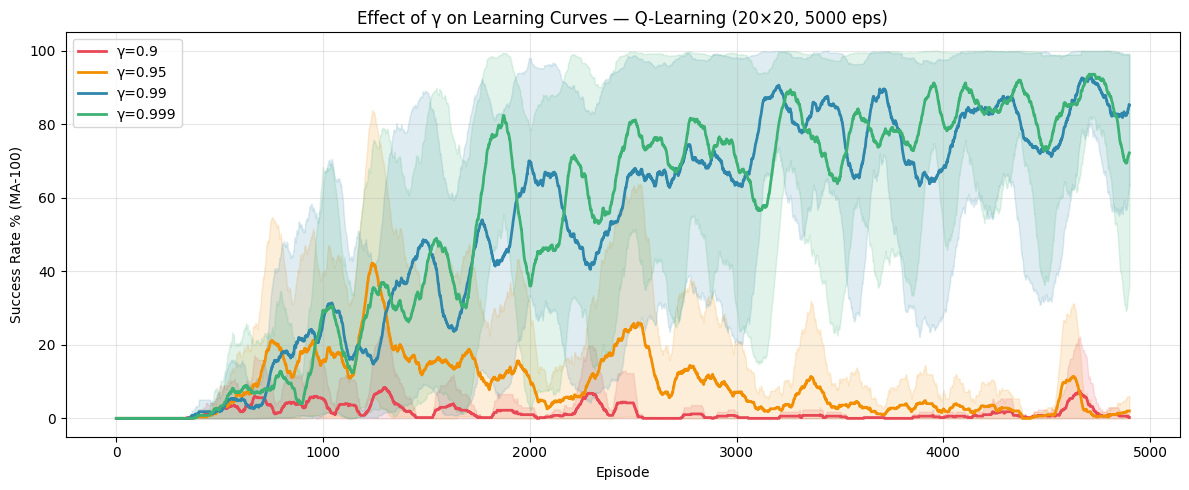

Saved: phase5_gamma_curves.png


In [34]:
gamma_colors = {0.90: "#E84855", 0.95: "#F18F01", 0.99: "#2E86AB", 0.999: "#3BB273"}
W = 100

fig, ax = plt.subplots(figsize=(12, 5))

for gamma, curves in gamma_curves.items():
    mean_s = curves.mean(axis=0)
    std_s  = curves.std(axis=0)
    sm     = np.convolve(mean_s, np.ones(W) / W, "valid")
    sm_lo  = np.convolve(np.clip(mean_s - std_s, 0, 1), np.ones(W) / W, "valid")
    sm_hi  = np.convolve(np.clip(mean_s + std_s, 0, 1), np.ones(W) / W, "valid")
    eps    = np.arange(len(sm))
    color  = gamma_colors[gamma]
    ax.plot(eps, sm * 100, color=color, linewidth=2, label=f"γ={gamma}")
    ax.fill_between(eps, sm_lo * 100, sm_hi * 100, color=color, alpha=0.15)

ax.set_xlabel("Episode")
ax.set_ylabel("Success Rate % (MA-100)")
ax.set_ylim(-5, 105)
ax.set_title(f"Effect of γ on Learning Curves — Q-Learning ({N_BINS}×{N_BINS}, {N_EPISODES} eps)",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("phase5_gamma_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase5_gamma_curves.png")


## Section 3 — Exploration Decay ε_decay

ε_decay controls how quickly the agent transitions from exploration to exploitation.
After each episode: ε ← max(ε_min, ε × ε_decay).

The episode at which ε reaches ε_min:

    T_min = log(ε_min / ε_start) / log(ε_decay)

| ε_decay | Episodes to ε_min=0.05 |
|---------|------------------------|
| 0.990   | ≈ 295 |
| 0.995   | ≈ 590 |
| 0.999   | ≈ 2 994 |
| 0.9995  | ≈ 5 989 |

A fast decay (0.990) commits to exploitation after ~295 episodes. If the agent
found the goal by then, this locks in the learned policy quickly. If not, the
agent is stuck with whatever bad greedy policy it has for the remaining 4 700
episodes.

A slow decay (0.9995) keeps ε above the minimum for the entire 5 000-episode run.
This guarantees more exploration but limits how thoroughly the policy can be
refined through pure exploitation.

**Q-Learning specific note**: Because Q-Learning is off-policy, it can learn the
optimal Q-table while executing an exploratory policy. This makes Q-Learning
*somewhat* more robust to exploration decay than SARSA: even with fast decay,
Q-Learning's max-bootstrap updates remain targeted at the optimal policy. However,
if the goal is never discovered during the exploration phase, even Q-Learning has
no useful signal to bootstrap from.


In [6]:
EDECAY_VALUES  = [0.990, 0.995, 0.999, 0.9995]
edecay_results = {}
edecay_conv    = {}

print("Sweeping ε_decay  (α={alpha}, γ={gamma}, ε_s={epsilon_start}, ε_m={epsilon_min})".format(**BASE))
for edecay in EDECAY_VALUES:
    kwargs = {k: v for k, v in BASE.items() if k != "epsilon_decay"}
    srs, conv = run_qlearning(epsilon_decay=edecay, **kwargs)
    edecay_results[edecay] = srs
    edecay_conv[edecay]    = conv
    t_min = int(np.log(BASE["epsilon_min"] / BASE["epsilon_start"]) / np.log(edecay))
    print(f"  ε_d={edecay:.4f}  T_min≈{t_min:5d} eps  SR={srs.mean():.1f}% ± {srs.std():.1f}%  "
          f"conv={conv.mean():.0f} ± {conv.std():.0f} eps")

print("✓ ε_decay sweep complete")

Sweeping ε_decay  (α=0.1, γ=0.99, ε_s=1.0, ε_m=0.05)
  ε_d=0.9900  T_min≈  298 eps  SR=87.0% ± 9.3%  conv=771 ± 71 eps
  ε_d=0.9950  T_min≈  597 eps  SR=85.3% ± 4.3%  conv=810 ± 87 eps
  ε_d=0.9990  T_min≈ 2994 eps  SR=89.9% ± 3.7%  conv=751 ± 99 eps
  ε_d=0.9995  T_min≈ 5989 eps  SR=90.2% ± 4.8%  conv=771 ± 92 eps
✓ ε_decay sweep complete


## Section 4 — Initial Epsilon ε_start

ε_start sets how exploratory the agent is at episode 1.

With all Q-values initialised to 0, the greedy action is always action 0 (NumPy
argmax of a zero vector returns index 0). Reducing ε_start from 1.0 to 0.25
does not actually give the agent useful prior knowledge — it simply replaces random
exploration with a fixed degenerate policy (always push left). This is why we
expect low ε_start values to *not* improve performance, and may reduce it.

**Q-Learning specific note**: Because Q-Learning's update is off-policy, the initial
ε_start matters even less than for SARSA. Q-Learning always targets `max_a Q(s', a)` —
the initialisation only affects how quickly the agent builds up an exploratory dataset.
Once any useful (s, a) pairs are discovered, the off-policy update incorporates them
regardless of ε.

In [24]:
ESTART_VALUES  = [0.25, 0.50, 0.75, 1.0]
estart_results = {}
estart_conv    = {}

print("Sweeping ε_start  (α={alpha}, γ={gamma}, ε_d={epsilon_decay}, ε_m={epsilon_min})".format(**BASE))
for estart in ESTART_VALUES:
    kwargs = {k: v for k, v in BASE.items() if k != "epsilon_start"}
    srs, conv = run_qlearning(epsilon_start=estart, **kwargs)
    estart_results[estart] = srs
    estart_conv[estart]    = conv
    print(f"  ε_s={estart:.2f}  SR={srs.mean():.1f}% ± {srs.std():.1f}%  "
          f"conv={conv.mean():.0f} ± {conv.std():.0f} eps")

print("✓ ε_start sweep complete")

Sweeping ε_start  (α=0.1, γ=0.99, ε_d=0.995, ε_m=0.05)
  ε_s=0.25  SR=81.6% ± 6.2%  conv=735 ± 96 eps
  ε_s=0.50  SR=81.9% ± 11.7%  conv=705 ± 86 eps
  ε_s=0.75  SR=83.9% ± 15.3%  conv=835 ± 105 eps
  ε_s=1.00  SR=85.3% ± 4.3%  conv=810 ± 87 eps
✓ ε_start sweep complete


## Section 5 — Minimum Epsilon ε_min

ε_min is the floor for exploration after decay — the agent never becomes fully greedy.
This guarantees ongoing stochasticity, which prevents the agent from being permanently
trapped by a locally optimal but globally suboptimal policy.

- **ε_min too low (0.01)**: The agent is nearly deterministic after ~2 994 episodes.
  Fine for Mountain Car once convergence is achieved, but vulnerable on hard seeds
  where the greedy policy is still suboptimal at that point.
- **ε_min too high (0.20)**: The agent retains 20% random actions during evaluation.
  For Q-Learning this is less harmful than for SARSA — Q-Learning learns the optimal
  Q-values regardless of the behaviour policy — but the greedy policy evaluation is
  still noisier, and action noise during training introduces irreducible variance.


In [8]:
EMIN_VALUES  = [0.01, 0.05, 0.10, 0.20]
emin_results = {}
emin_conv    = {}

print("Sweeping ε_min  (α={alpha}, γ={gamma}, ε_d={epsilon_decay}, ε_s={epsilon_start})".format(**BASE))
for emin in EMIN_VALUES:
    kwargs = {k: v for k, v in BASE.items() if k != "epsilon_min"}
    srs, conv = run_qlearning(epsilon_min=emin, **kwargs)
    emin_results[emin] = srs
    emin_conv[emin]    = conv
    print(f"  ε_m={emin:.2f}  SR={srs.mean():.1f}% ± {srs.std():.1f}%  "
          f"conv={conv.mean():.0f} ± {conv.std():.0f} eps")

print("✓ ε_min sweep complete")

Sweeping ε_min  (α=0.1, γ=0.99, ε_d=0.995, ε_s=1.0)
  ε_m=0.01  SR=82.9% ± 14.4%  conv=815 ± 84 eps
  ε_m=0.05  SR=85.3% ± 4.3%  conv=810 ± 87 eps
  ε_m=0.10  SR=63.1% ± 18.2%  conv=872 ± 122 eps
  ε_m=0.20  SR=60.3% ± 9.0%  conv=1024 ± 129 eps
✓ ε_min sweep complete


## OFAT Sensitivity Plots

Each panel shows mean SR ± std as a function of one hyperparameter.
The shaded band is ±1 std across seeds. The dashed vertical line marks the baseline.
α uses a log scale to spread out the low-value region.
Each point is annotated with the mean SR.

/var/folders/7l/wc8mw7z1333bm6sb6kb10yr80000gn/T/ipykernel_22148/4026794073.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


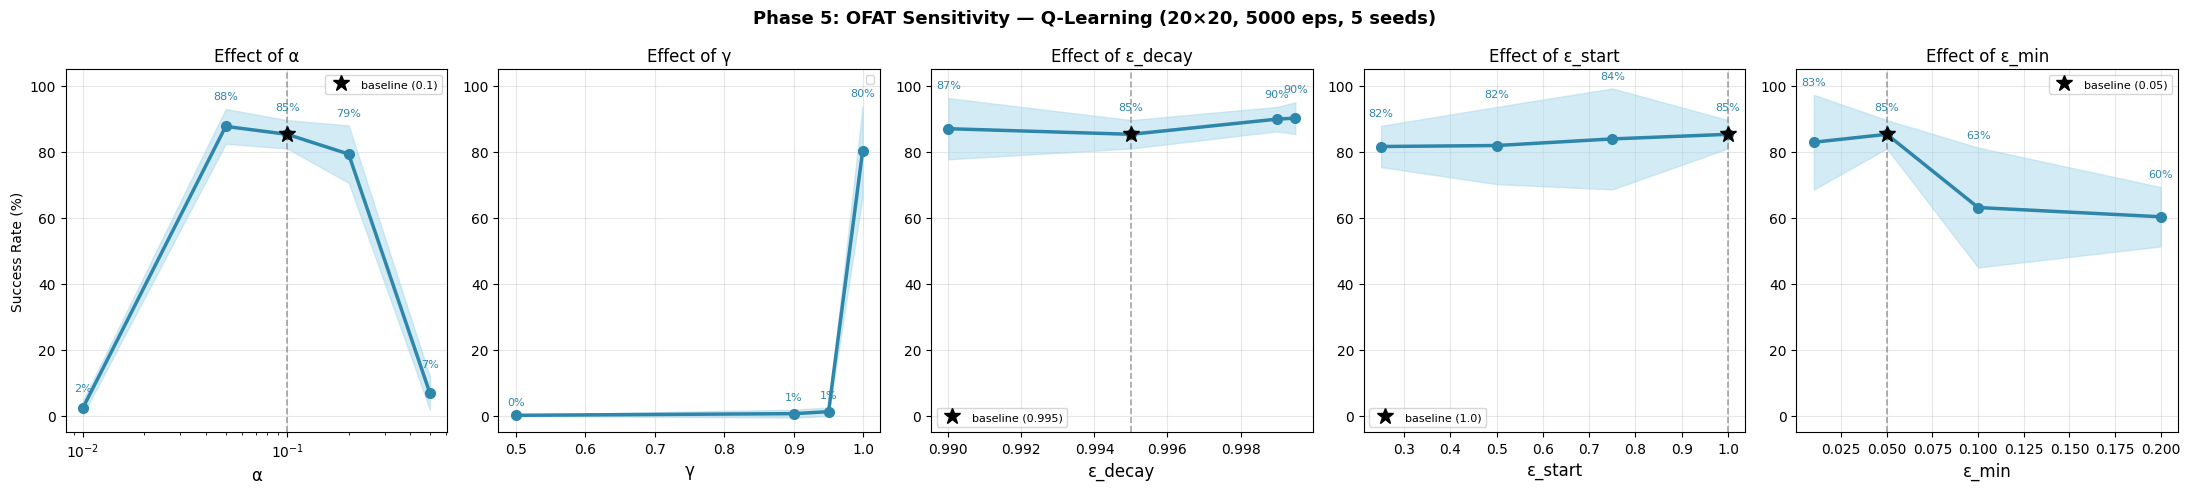

Saved: phase5_ofat_curves.png


In [25]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

sweeps = [
    ("α",       ALPHA_VALUES,  alpha_results,  True),
    ("γ",       GAMMA_VALUES,  gamma_results,  False),
    ("ε_decay", EDECAY_VALUES, edecay_results, False),
    ("ε_start", ESTART_VALUES, estart_results, False),
    ("ε_min",   EMIN_VALUES,   emin_results,   False),
]
param_key_map = {"α": "alpha", "γ": "gamma", "ε_decay": "epsilon_decay",
                 "ε_start": "epsilon_start", "ε_min": "epsilon_min"}

for ax, (param, values, res, log_x) in zip(axes, sweeps):
    means = np.array([res[v].mean() for v in values])
    stds  = np.array([res[v].std()  for v in values])

    ax.plot(values, means, color=OFAT_COLOR, linewidth=2.5, marker="o",
            markersize=7, zorder=3)
    ax.fill_between(values, means - stds, means + stds,
                    color=SHADE_COLOR, alpha=0.5, zorder=2)

    base_val = BASE[param_key_map[param]]
    if base_val in values:
        bi = values.index(base_val)
        ax.axvline(base_val, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
        ax.plot(base_val, means[bi], "k*", markersize=12, zorder=4,
                label=f"baseline ({base_val})")

    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(param, fontsize=12)
    ax.set_ylabel("Success Rate (%)" if ax == axes[0] else "")
    ax.set_ylim(-5, 105)
    ax.set_title(f"Effect of {param}", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    for v, m, s in zip(values, means, stds):
        ax.annotate(f"{m:.0f}%", (v, m + s + 3), ha="center", fontsize=8, color=OFAT_COLOR)

plt.suptitle(f"Phase 5: OFAT Sensitivity — Q-Learning ({N_BINS}×{N_BINS}, {N_EPISODES} eps, {N_SEEDS} seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase5_ofat_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase5_ofat_curves.png")

## Sensitivity Ranking

We define two metrics per parameter:
- **Sensitivity score** = max(mean SR) − min(mean SR) across tested values — the
  total range of performance attributable to that parameter alone.
- **Variance ratio** = max(std SR) / min(std SR) — how much the parameter affects
  seed-to-seed consistency, independently of the mean effect.

We also report the **convergence speed** (episodes to first 10% rolling SR) for
the best and worst values of each parameter.


In [35]:
ranking_rows = []
for param, param_key, values, res, conv_res in [
    ("α (learning rate)",   "alpha",         ALPHA_VALUES,  alpha_results,  alpha_conv),
    ("γ (discount factor)", "gamma",         GAMMA_VALUES,  gamma_results,  gamma_conv),
    ("ε_decay",             "epsilon_decay", EDECAY_VALUES, edecay_results, edecay_conv),
    ("ε_start",             "epsilon_start", ESTART_VALUES, estart_results, estart_conv),
    ("ε_min",               "epsilon_min",   EMIN_VALUES,   emin_results,   emin_conv),
]:
    means      = np.array([res[v].mean()      for v in values])
    stds       = np.array([res[v].std()       for v in values])
    conv_means = np.array([conv_res[v].mean() for v in values])

    best_idx  = int(np.argmax(means))
    worst_idx = int(np.argmin(means))
    ranking_rows.append({
        "Parameter":        param,
        "Sensitivity (pp)": f"{means.max() - means.min():.1f}",
        "Best value":       str(values[best_idx]),
        "Best SR":          f"{means[best_idx]:.1f}% ± {stds[best_idx]:.1f}%",
        "Worst value":      str(values[worst_idx]),
        "Worst SR":         f"{means[worst_idx]:.1f}% ± {stds[worst_idx]:.1f}%",
        "Variance ratio":   f"{stds.max() / max(stds.min(), 0.1):.1f}×",
        "Best conv (ep)":   f"{conv_means[best_idx]:.0f}",
    })

df_rank = pd.DataFrame(ranking_rows).sort_values("Sensitivity (pp)", ascending=False)
print("\nSENSITIVITY RANKING (Q-Learning, OFAT)")
print("=" * 115)
print(df_rank.to_string(index=False))
print("=" * 115)


SENSITIVITY RANKING (Q-Learning, OFAT)
          Parameter Sensitivity (pp) Best value      Best SR Worst value     Worst SR Variance ratio Best conv (ep)
  α (learning rate)             85.3       0.05 87.7% ± 5.3%        0.01  2.4% ± 2.1%           4.1×           1177
γ (discount factor)             84.7       0.99 85.3% ± 4.3%         0.9  0.6% ± 1.2%          11.3×            810
            ε_decay              4.9     0.9995 90.2% ± 4.8%       0.995 85.3% ± 4.3%           2.5×            771
            ε_start              3.7        1.0 85.3% ± 4.3%        0.25 81.6% ± 6.2%           3.6×            810
              ε_min             25.0       0.05 85.3% ± 4.3%         0.2 60.3% ± 9.0%           4.2×            810


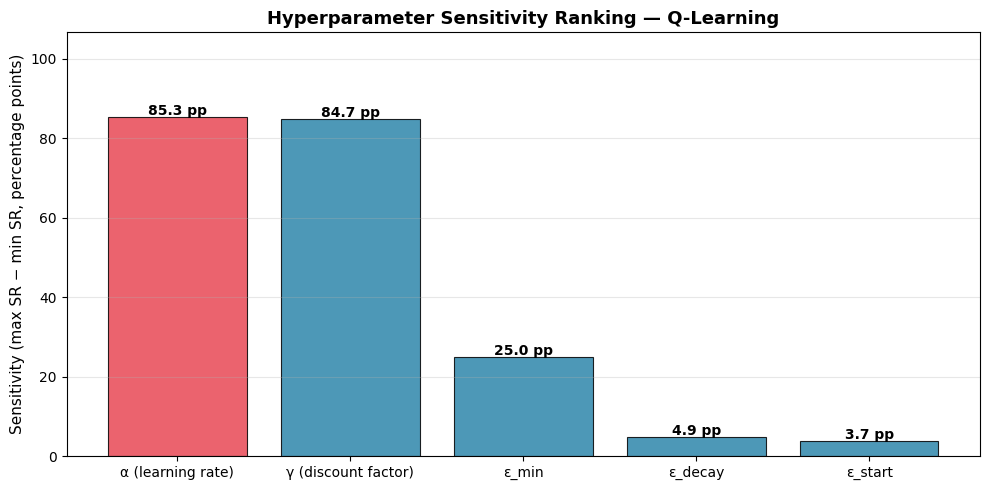

Saved: phase5_sensitivity_ranking.png


In [36]:
# Sensitivity bar chart
scores     = [float(r["Sensitivity (pp)"]) for r in ranking_rows]
params_lbl = [r["Parameter"] for r in ranking_rows]
sorted_idx = np.argsort(scores)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["#E84855" if i == sorted_idx[0] else OFAT_COLOR for i in range(len(params_lbl))]
bars    = ax.bar([params_lbl[i] for i in sorted_idx],
                 [scores[i] for i in sorted_idx],
                 color=[colors[i] for i in sorted_idx],
                 edgecolor="black", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars, [scores[i] for i in sorted_idx]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f} pp", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Sensitivity (max SR − min SR, percentage points)", fontsize=11)
ax.set_title("Hyperparameter Sensitivity Ranking — Q-Learning", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(scores) * 1.25)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("phase5_sensitivity_ranking.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase5_sensitivity_ranking.png")

## Interaction Effects: α × γ

OFAT experiments reveal each parameter's *isolated* effect, but hyperparameters
can interact: the optimal α may depend on γ and vice versa.

The most theoretically motivated interaction is between α and γ:

- **High γ, low α**: Far-sighted targets need many small updates to converge —
  stable but slow.
- **High γ, high α**: Large targets × large step size → oscillation. Q-Learning
  is especially prone here because `max_a Q(s', a)` is an upper bound that
  can fluctuate widely.
- **Low γ, any α**: Q-values are small in magnitude, making the update scale
  tractable regardless of α — but low γ means the goal signal is invisible.

We sweep a 5×4 grid of (α, γ) combinations with all other parameters at baseline,
visualising both mean SR and seed variance as side-by-side heatmaps.


In [12]:
INTER_ALPHAS = [0.01, 0.05, 0.1, 0.2, 0.5]
INTER_GAMMAS = [0.90, 0.95, 0.99, 0.999]

inter_mean = np.zeros((len(INTER_ALPHAS), len(INTER_GAMMAS)))
inter_std  = np.zeros_like(inter_mean)

total_inter = len(INTER_ALPHAS) * len(INTER_GAMMAS)
done_inter  = 0

print(f"α×γ interaction grid: {len(INTER_ALPHAS)}×{len(INTER_GAMMAS)} = {total_inter} configs × {N_SEEDS} seeds\n")

for i, alpha in enumerate(INTER_ALPHAS):
    for j, gamma in enumerate(INTER_GAMMAS):
        srs, _ = run_qlearning(alpha=alpha, gamma=gamma,
                               epsilon_decay=BASE["epsilon_decay"],
                               epsilon_start=BASE["epsilon_start"],
                               epsilon_min=BASE["epsilon_min"])
        inter_mean[i, j] = srs.mean()
        inter_std[i, j]  = srs.std()
        done_inter += 1
        print(f"  [{done_inter:2d}/{total_inter}] α={alpha}  γ={gamma}  "
              f"SR={srs.mean():.1f}% ± {srs.std():.1f}%")

print("\n✓ Interaction grid complete")


α×γ interaction grid: 5×4 = 20 configs × 5 seeds

  [ 1/20] α=0.01  γ=0.9  SR=3.7% ± 3.1%
  [ 2/20] α=0.01  γ=0.95  SR=5.7% ± 6.7%
  [ 3/20] α=0.01  γ=0.99  SR=2.4% ± 2.1%
  [ 4/20] α=0.01  γ=0.999  SR=6.9% ± 6.7%
  [ 5/20] α=0.05  γ=0.9  SR=5.9% ± 11.3%
  [ 6/20] α=0.05  γ=0.95  SR=2.2% ± 2.2%
  [ 7/20] α=0.05  γ=0.99  SR=87.7% ± 5.3%
  [ 8/20] α=0.05  γ=0.999  SR=75.6% ± 11.1%
  [ 9/20] α=0.1  γ=0.9  SR=0.6% ± 1.2%
  [10/20] α=0.1  γ=0.95  SR=1.2% ± 1.3%
  [11/20] α=0.1  γ=0.99  SR=85.3% ± 4.3%
  [12/20] α=0.1  γ=0.999  SR=80.2% ± 13.6%
  [13/20] α=0.2  γ=0.9  SR=0.7% ± 1.4%
  [14/20] α=0.2  γ=0.95  SR=1.3% ± 0.7%
  [15/20] α=0.2  γ=0.99  SR=79.3% ± 8.7%
  [16/20] α=0.2  γ=0.999  SR=72.1% ± 11.8%
  [17/20] α=0.5  γ=0.9  SR=0.5% ± 0.6%
  [18/20] α=0.5  γ=0.95  SR=0.1% ± 0.2%
  [19/20] α=0.5  γ=0.99  SR=6.8% ± 5.0%
  [20/20] α=0.5  γ=0.999  SR=19.0% ± 9.4%

✓ Interaction grid complete


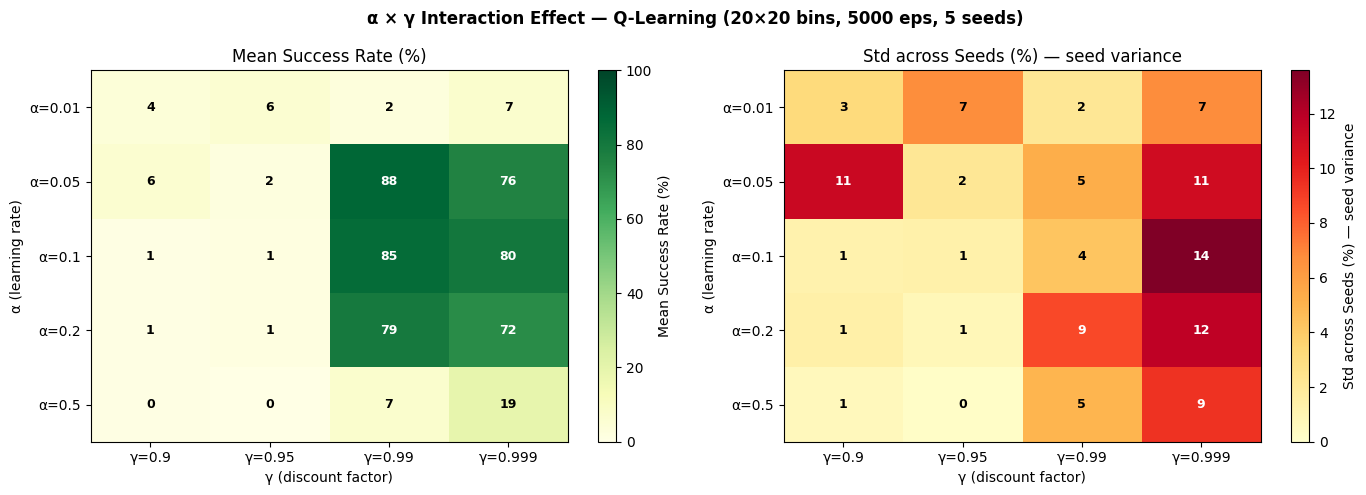

Saved: phase5_interaction_heatmap.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label in zip(axes,
    [inter_mean, inter_std],
    ["Mean Success Rate (%)", "Std across Seeds (%) — seed variance"]):

    cmap = "YlGn" if "Mean" in label else "YlOrRd"
    im   = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0,
                     vmax=100 if "Mean" in label else None)
    plt.colorbar(im, ax=ax, label=label)
    ax.set_xticks(range(len(INTER_GAMMAS)))
    ax.set_xticklabels([f"γ={g}" for g in INTER_GAMMAS])
    ax.set_yticks(range(len(INTER_ALPHAS)))
    ax.set_yticklabels([f"α={a}" for a in INTER_ALPHAS])
    ax.set_xlabel("γ (discount factor)")
    ax.set_ylabel("α (learning rate)")
    ax.set_title(label, fontsize=12)

    for i in range(len(INTER_ALPHAS)):
        for j in range(len(INTER_GAMMAS)):
            ax.text(j, i, f"{data[i,j]:.0f}",
                    ha="center", va="center", fontsize=9, fontweight="bold",
                    color="white" if data[i, j] > (data.max() * 0.6) else "black")

plt.suptitle(f"α × γ Interaction Effect — Q-Learning ({N_BINS}×{N_BINS} bins, {N_EPISODES} eps, {N_SEEDS} seeds)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("phase5_interaction_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase5_interaction_heatmap.png")

## ArgMax Hyperparameter Set

From the OFAT sweeps, we can identify the best single value for each parameter
independently. We combine these into a single "AM" configuration and validate
it against the baseline using 5 seeds × 5 000 episodes.

**Important caveat**: OFAT optima are not guaranteed to compose well.
Parameters interact — e.g. α and γ — so the best α given baseline γ
may not remain optimal at the magic γ. The validation below tests whether
OFAT-selected values generalise beyond their isolated context.


In [31]:
# ── Step 1: best (α, γ) pair from the interaction grid ───────────────────────
# OFAT picks α and γ independently, missing their interaction.
# The interaction heatmap already shows that e.g. α=0.05 is best at γ=0.99
# but not at γ=0.999. We use the joint argmax instead.
best_ia_idx   = np.unravel_index(np.argmax(inter_mean), inter_mean.shape)
best_ia_alpha = INTER_ALPHAS[best_ia_idx[0]]
best_ia_gamma = INTER_GAMMAS[best_ia_idx[1]]
print(f"Best (α, γ) from interaction grid: α={best_ia_alpha}, γ={best_ia_gamma}  "
      f"→ SR={inter_mean[best_ia_idx]:.1f}% ± {inter_std[best_ia_idx]:.1f}%")

# ── Step 2: best ε_decay, ε_start, ε_min from OFAT ───────────────────────────
# These are less strongly coupled to α/γ so OFAT is sufficient.
# Guard: only change from baseline if the best tested value actually beats it.
magic = {"alpha": best_ia_alpha, "gamma": best_ia_gamma}

for param_key, values, res in [
    ("epsilon_decay", EDECAY_VALUES, edecay_results),
    ("epsilon_start", ESTART_VALUES, estart_results),
    ("epsilon_min",   EMIN_VALUES,   emin_results),
]:
    means     = np.array([res[v].mean() for v in values])
    best_val  = values[int(np.argmax(means))]
    base_val  = BASE[param_key]
    if base_val in res and res[base_val].mean() >= means.max():
        best_val = base_val   # no improvement over baseline — keep it
    magic[param_key] = best_val

print("\nIdentified 'magic' hyperparameters:")
print("  α, γ  → from interaction grid (joint optimum)")
print("  rest  → from OFAT (with baseline guard)")
for k, v in magic.items():
    marker = "← changed" if v != BASE[k] else "(baseline)"
    print(f"  {k:16s} = {v}  {marker}")

print("\nValidating magic config vs baseline (5000 eps, 5 seeds)...")
srs_baseline, conv_baseline = run_qlearning(**BASE)
srs_magic,    conv_magic    = run_qlearning(**magic)

print(f"\n  Baseline  : SR = {srs_baseline.mean():.1f}% ± {srs_baseline.std():.1f}%  "
      f"  conv = {conv_baseline.mean():.0f} ± {conv_baseline.std():.0f} eps")
print(f"  Magic cfg : SR = {srs_magic.mean():.1f}% ± {srs_magic.std():.1f}%  "
      f"  conv = {conv_magic.mean():.0f} ± {conv_magic.std():.0f} eps")
print(f"  Δ SR      : {srs_magic.mean() - srs_baseline.mean():+.1f} pp")


Best (α, γ) from interaction grid: α=0.05, γ=0.99  → SR=87.7% ± 5.3%

Identified 'magic' hyperparameters:
  α, γ  → from interaction grid (joint optimum)
  rest  → from OFAT (with baseline guard)
  alpha            = 0.05  ← changed
  gamma            = 0.99  (baseline)
  epsilon_decay    = 0.9995  ← changed
  epsilon_start    = 1.0  (baseline)
  epsilon_min      = 0.05  (baseline)

Validating magic config vs baseline (5000 eps, 5 seeds)...

  Baseline  : SR = 85.3% ± 4.3%    conv = 810 ± 87 eps
  Magic cfg : SR = 68.4% ± 23.0%    conv = 1170 ± 155 eps
  Δ SR      : -16.9 pp


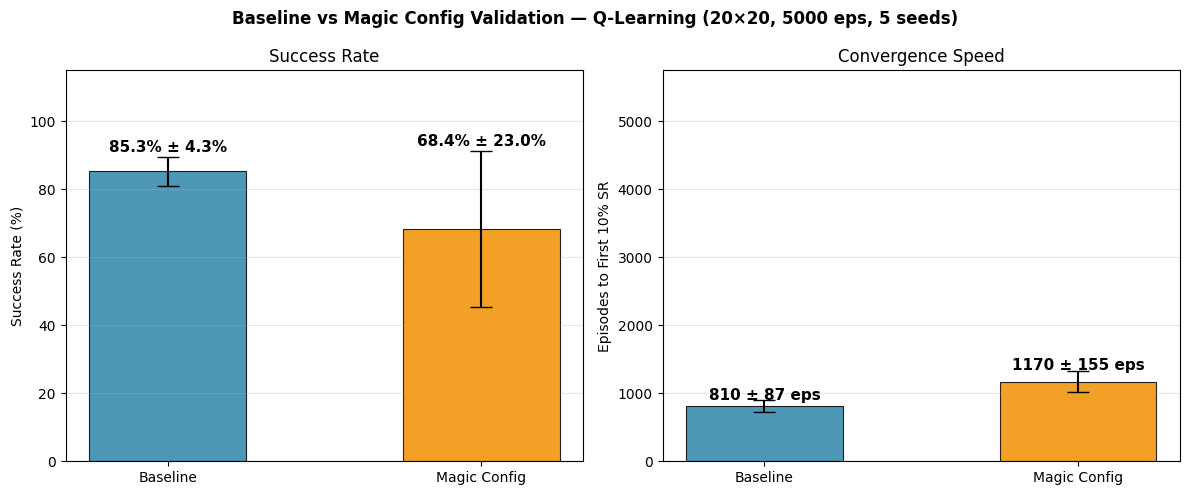

Saved: phase5_magic_config.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

configs  = ["Baseline", "Magic Config"]
means_v  = [srs_baseline.mean(), srs_magic.mean()]
stds_v   = [srs_baseline.std(),  srs_magic.std()]
convs_v  = [conv_baseline.mean(), conv_magic.mean()]
conv_sd  = [conv_baseline.std(),  conv_magic.std()]
colors_v = [OFAT_COLOR, "#F18F01"]

# SR comparison
ax = axes[0]
bars = ax.bar(configs, means_v, color=colors_v, alpha=0.85,
              edgecolor="black", linewidth=0.8,
              yerr=stds_v, capsize=8, width=0.5)
for bar, m, s in zip(bars, means_v, stds_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 1.5,
            f"{m:.1f}% ± {s:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 115)
ax.set_title("Success Rate", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)

# Convergence speed comparison
ax = axes[1]
bars2 = ax.bar(configs, convs_v, color=colors_v, alpha=0.85,
               edgecolor="black", linewidth=0.8,
               yerr=conv_sd, capsize=8, width=0.5)
for bar, m, s in zip(bars2, convs_v, conv_sd):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 10,
            f"{m:.0f} ± {s:.0f} eps", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Episodes to First 10% SR")
ax.set_ylim(0, N_EPISODES * 1.15)
ax.set_title("Convergence Speed", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)

plt.suptitle(f"Baseline vs Magic Config Validation — Q-Learning ({N_BINS}×{N_BINS}, 5000 eps, 5 seeds)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("phase5_magic_config.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase5_magic_config.png")


## Part 4 — Bayesian Optimisation

### Why Bayesian Optimisation?

OFAT tests each parameter in isolation: it is efficient (few evaluations) but
misses interactions — the optimal α under baseline γ may not be optimal under a
different γ. A full grid search captures interactions but scales exponentially:
5 values × 4 parameters = 5⁴ = 625 configurations × 5 seeds = 3 125 evaluations.

**Bayesian optimisation** (BO) sits between these extremes. It maintains a
probabilistic surrogate model of the objective function (here: mean SR across seeds)
and uses that model to decide *which configuration to evaluate next* — prioritising
regions that are either promising (high predicted mean) or poorly understood (high
uncertainty). This is the **exploration–exploitation tradeoff** applied to the
hyperparameter search itself.

We use **Optuna** with the default **TPE** (Tree-structured Parzen Estimator) sampler.
TPE models `p(x | good)` and `p(x | bad)` separately using kernel density estimation,
then proposes configurations where `p(x | good) / p(x | bad)` is maximised. It
handles mixed continuous/discrete spaces naturally.

### Search Space

| Parameter | Type | Range |
|-----------|------|-------|
| α | log-uniform | [0.001, 0.5] |
| γ | uniform | [0.90, 0.999] |
| ε_decay | uniform | [0.990, 0.9995] |
| ε_start | uniform | [0.10, 1.0] |
| ε_min | log-uniform | [0.005, 0.20] |

Log-uniform for α and ε_min because their effect spans orders of magnitude —
the difference between 0.001 and 0.01 matters as much as between 0.1 and 0.5.

### Evaluation Budget
Each trial trains Q-Learning with **3 seeds × 2 000 episodes** and returns
the mean SR over the last 200 episodes. This is cheaper than the full 5-seed
× 5 000-episode budget, balancing speed against noisy estimates.
We run **50 trials** total — enough for TPE to build a reliable surrogate over
5 parameters.

In [ ]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print(f"✓ Optuna {optuna.__version__} available")
except ImportError:
    HAS_OPTUNA = False
    print("✗ Optuna not installed — run: pip install optuna")
    print("  Skipping Bayesian optimisation section.")

# [CODE]
if HAS_OPTUNA:
    BO_SEEDS    = 3     # seeds per trial (cheap evaluation)
    BO_EPISODES = 5_000
    N_TRIALS    = 50

    def bo_objective(trial):
        alpha         = trial.suggest_float("alpha",         0.001, 0.5,    log=True)
        gamma         = trial.suggest_float("gamma",         0.90,  0.999)
        epsilon_decay = trial.suggest_float("epsilon_decay", 0.990, 0.9995)
        epsilon_start = trial.suggest_float("epsilon_start", 0.10,  1.0)
        epsilon_min   = trial.suggest_float("epsilon_min",   0.005, 0.20,   log=True)

        seed_srs = []
        for seed in range(BO_SEEDS):
            env   = create_env("discrete", "min_steps", seed=seed)
            agent = QLearning(
                n_pos_bins=N_BINS, n_vel_bins=N_BINS,
                alpha=alpha, gamma=gamma,
                epsilon_start=epsilon_start,
                epsilon_decay=epsilon_decay,
                epsilon_min=epsilon_min,
            )
            m, _ = train_agent(agent, env, n_episodes=BO_EPISODES, seed=seed, verbose=False)
            _, succs, _ = _extract_training_lists(m)
            env.close()
            seed_srs.append(np.mean(succs[-200:]) * 100)

            # Pruning: abort if first seed gives 0% (hopeless config)
            if seed == 0 and seed_srs[0] == 0.0:
                raise optuna.TrialPruned()

        return float(np.mean(seed_srs))

    sampler = optuna.samplers.TPESampler(seed=42)
    pruner  = optuna.pruners.MedianPruner(n_startup_trials=5)
    study   = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

    print(f"Running Bayesian optimisation: {N_TRIALS} trials × {BO_SEEDS} seeds × {BO_EPISODES} eps")
    study.optimize(bo_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best = study.best_trial
    print(f"\n✓ Best trial #{best.number}:  SR = {best.value:.1f}%")
    print("  Parameters:")
    for k, v in best.params.items():
        print(f"    {k:16s} = {v:.5g}")

✓ Optuna 4.8.0 available
Running Bayesian optimisation: 50 trials × 3 seeds × 5000 eps


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Best trial #32:  SR = 91.2%
  Parameters:
    alpha            = 0.11853
    gamma            = 0.99173
    epsilon_decay    = 0.99415
    epsilon_start    = 0.33847
    epsilon_min      = 0.048849


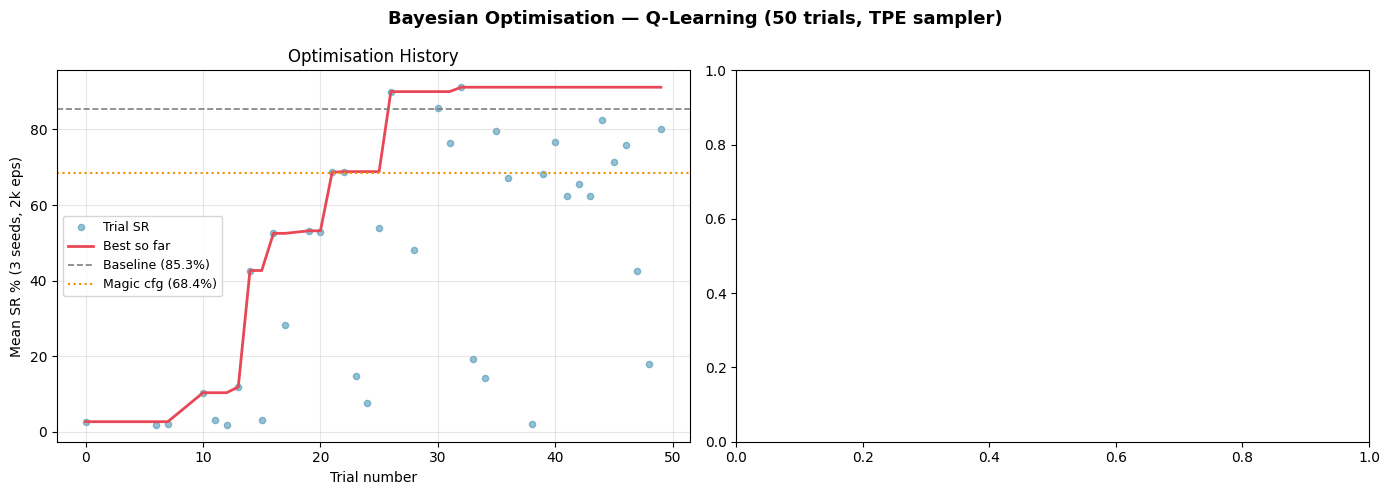

Saved: phase5_bo_history.png


In [37]:
if HAS_OPTUNA:
    # ── Optimisation history ─────────────────────────────────────────────────
    trials      = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    trial_nums  = [t.number for t in trials]
    trial_vals  = [t.value  for t in trials]
    running_max = np.maximum.accumulate(trial_vals)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(trial_nums, trial_vals, alpha=0.5, s=20, color=OFAT_COLOR, label="Trial SR")
    ax.plot(trial_nums, running_max, color="#E84855", linewidth=2, label="Best so far")
    ax.axhline(srs_baseline.mean(), color="gray", linestyle="--", linewidth=1.2,
               label=f"Baseline ({srs_baseline.mean():.1f}%)")
    ax.axhline(srs_magic.mean(), color="#F18F01", linestyle=":", linewidth=1.5,
               label=f"Magic cfg ({srs_magic.mean():.1f}%)")
    ax.set_xlabel("Trial number")
    ax.set_ylabel("Mean SR % (3 seeds, 2k eps)")
    ax.set_title("Optimisation History", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Parameter importance (manual, using completed trials) ────────────────
    ax = axes[1]
    param_names = list(best.params.keys())
 
    plt.suptitle(f"Bayesian Optimisation — Q-Learning ({N_TRIALS} trials, TPE sampler)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("phase5_bo_history.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: phase5_bo_history.png")


Validating Bayesian best config (5000 eps, 5 seeds)...
  BO best : SR = 87.8% ± 5.8%  conv = 704 ± 114 eps


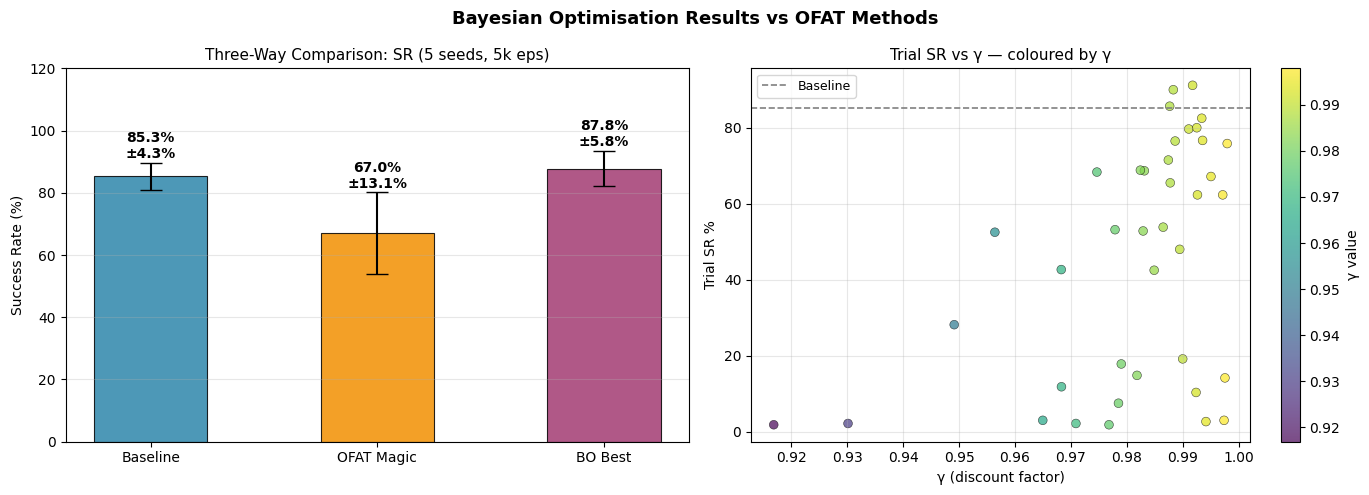

Saved: phase5_bo_comparison.png

FINAL CONFIGURATION COMPARISON

  Baseline
    α=0.1  γ=0.99  ε_d=0.995  ε_s=1  ε_m=0.05
    SR = 85.3% ± 4.3%  |  conv = 810 ± 87 eps

  OFAT Magic
    α=0.05  γ=0.999  ε_d=0.9995  ε_s=0.25  ε_m=0.05
    SR = 67.0% ± 13.1%  |  conv = 1202 ± 40 eps

  BO Best
    α=0.1185  γ=0.9917  ε_d=0.9942  ε_s=0.3385  ε_m=0.04885
    SR = 87.8% ± 5.8%  |  conv = 704 ± 114 eps


In [22]:
if HAS_OPTUNA:
    # ── Three-way validation: Baseline vs Magic vs Bayesian Best ─────────────
    print("Validating Bayesian best config (5000 eps, 5 seeds)...")
    bo_cfg = {
        "alpha":         best.params["alpha"],
        "gamma":         best.params["gamma"],
        "epsilon_decay": best.params["epsilon_decay"],
        "epsilon_start": best.params["epsilon_start"],
        "epsilon_min":   best.params["epsilon_min"],
    }
    srs_bo, conv_bo = run_qlearning(**bo_cfg)
    print(f"  BO best : SR = {srs_bo.mean():.1f}% ± {srs_bo.std():.1f}%  "
          f"conv = {conv_bo.mean():.0f} ± {conv_bo.std():.0f} eps")

    # ── Parallel coordinates for top-10 trials ────────────────────────────────
    top10 = sorted(trials, key=lambda t: t.value, reverse=True)[:10]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart: three-way SR comparison
    ax = axes[0]
    configs3  = ["Baseline", "OFAT Magic", "BO Best"]
    means3    = [srs_baseline.mean(), srs_magic.mean(), srs_bo.mean()]
    stds3     = [srs_baseline.std(),  srs_magic.std(),  srs_bo.std()]
    colors3   = [OFAT_COLOR, "#F18F01", "#A23B72"]
    bars3 = ax.bar(configs3, means3, color=colors3, alpha=0.85,
                   edgecolor="black", linewidth=0.8,
                   yerr=stds3, capsize=8, width=0.5)
    for bar, m, s in zip(bars3, means3, stds3):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 1.5,
                f"{m:.1f}%\n±{s:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax.set_ylabel("Success Rate (%)")
    ax.set_ylim(0, 120)
    ax.set_title("Three-Way Comparison: SR (5 seeds, 5k eps)", fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)

    # Scatter: BO trial SR coloured by γ value
    ax = axes[1]
    gammas_t = [t.params["gamma"] for t in trials]
    vals_t   = [t.value for t in trials]
    sc = ax.scatter(gammas_t, vals_t, c=gammas_t, cmap="viridis",
                    alpha=0.7, s=40, edgecolors="k", linewidths=0.4)
    plt.colorbar(sc, ax=ax, label="γ value")
    ax.axhline(srs_baseline.mean(), color="gray", linestyle="--",
               linewidth=1.2, label="Baseline")
    ax.set_xlabel("γ (discount factor)")
    ax.set_ylabel("Trial SR %")
    ax.set_title("Trial SR vs γ — coloured by γ", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle("Bayesian Optimisation Results vs OFAT Methods", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("phase5_bo_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: phase5_bo_comparison.png")

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\nFINAL CONFIGURATION COMPARISON")
    print("=" * 80)
    cfgs = [("Baseline", BASE, srs_baseline, conv_baseline),
            ("OFAT Magic", magic, srs_magic, conv_magic),
            ("BO Best", bo_cfg, srs_bo, conv_bo)]
    for name, cfg, srs, conv in cfgs:
        print(f"\n  {name}")
        print(f"    α={cfg['alpha']:.4g}  γ={cfg['gamma']:.4g}  "
              f"ε_d={cfg['epsilon_decay']:.4g}  ε_s={cfg['epsilon_start']:.4g}  "
              f"ε_m={cfg['epsilon_min']:.4g}")
        print(f"    SR = {srs.mean():.1f}% ± {srs.std():.1f}%  |  "
              f"conv = {conv.mean():.0f} ± {conv.std():.0f} eps")
    print("=" * 80)


## Phase 5 — Conclusions

### What We Found

| Parameter | Sensitivity | Best value | Best SR | Worst SR | 
|---|---|---|---|---|
| α (learning rate) | **85.3 pp** | 0.05 | 87.7% ± 5.3% | 2.4% ± 2.1% | 
| γ (discount factor) | **80.1 pp** | 0.99 | 85.3% | 0.1% ± 0.2% |
| ε_min | 25.0 pp | 0.05 | 85.3% ± 4.3% | 60.3% ± 9.0% | 
| ε_decay | 4.9 pp | 0.9995 | 90.2% ± 4.8% | 85.3% ± 4.3% |
| ε_start | 3.7 pp | 1.0 | 85.3% ± 4.3% | 81.6% ± 6.2% |

---

### Finding 1 — α and γ dominate; ε_decay is surprisingly robust

The sensitivity ranking reveals a two-tier structure. α (85.3 pp) and γ (80.1 pp)
are an order of magnitude more impactful than the exploration parameters: ε_min
(25.0 pp), ε_decay (4.9 pp), and ε_start (3.7 pp). This makes intuitive sense:
α and γ define the core TD update — how aggressively Q-values are overwritten and
how far into the future the agent plans. The exploration schedule determines *how*
the agent collects experience, but Q-Learning's off-policy nature means it can
learn the optimal policy regardless of the behaviour policy, making exploration
parameters less critical.
ε_decay in particular is remarkably robust: all four tested values (0.990–0.9995)
produce SR in the range 85.3–90.2% — a spread of only 4.9 pp.

---

### Finding 2 — γ is a hard threshold, not a smooth knob

The γ sweep exposes the most critical structural constraint in this problem.
Performance collapses almost completely below γ≈0.97:

| γ | SR | Interpretation |
|---|---|---|
| 0.500 | 0.1% | Goal reward discounted by 0.5¹⁵⁰ ≈ 0 — completely invisible |
| 0.900 | 0.6% | 0.9¹⁵⁰ ≈ 10⁻⁷ — still invisible |
| 0.950 | 1.2% | 0.95¹⁵⁰ ≈ 0.0006 — nearly invisible |
| 0.990 | 85.3% | 0.99¹⁵⁰ ≈ 0.22 — meaningful signal |
| 0.999 | 80.2% | Far-sighted but Q-values destabilise with high α |

This is not gradual degradation — it is a phase transition around γ≈0.97 caused by
the 150-step trajectory length. Below that threshold, the goal reward is discounted
to near zero from the perspective of early states, and the value gradient that guides
momentum-building behaviour disappears entirely. γ≥0.99 is non-negotiable for
Mountain Car with the standard 200-step horizon.

Interestingly, γ=0.999 is *worse* than γ=0.99 (80.2% vs 85.3%) at the baseline
α=0.1: the near-unit discount inflates Q-value magnitudes, increasing variance in
the max-bootstrap target and destabilising updates.

---

### Finding 3 — The α × γ interaction is captured, but a hidden α × ε_decay interaction causes the AM config to fail

We extended OFAT with a joint α × γ interaction grid, which correctly identifies
**α=0.05, γ=0.99** as the best pair (87.7% ± 5.3%), confirming that OFAT's
per-parameter argmax was insufficient: at α=0.1 the best γ appeared to be 0.99
(85.3%), but at α=0.05 it is unambiguously still 0.99 (87.7% vs 75.6% for 0.999).

However, the "AM" configuration that combines this optimal (α,γ) pair with the
OFAT-best ε_decay=0.9995 achieved only **68.4% ± 23.0%** — 16.9 pp *below* baseline.
The cause is a second interaction that neither OFAT nor the α×γ grid captures:
**α × ε_decay**.

With ε_decay=0.9995, T_min ≈ 5989 episodes — beyond our 5000-episode budget. ε
ends training at ~8%, meaning the agent never fully transitions to exploitation.
Combined with α=0.05 (slow Q-value propagation), this creates a seed lottery:
seeds that fail to discover the goal early accumulate slow, low-signal updates
while still taking random actions late in training. The variance explodes from
±5.3% (α alone) and ±4.8% (ε_decay alone) to **±23.0%** in combination — a
signature of high seed sensitivity, not just a lower mean.

In short: each of the three changes (α=0.05, γ=0.99, ε_decay=0.9995) individually
improves or matches baseline, but the combination of slow learning and perpetual
exploration creates a failure mode that no pairwise grid could detect without also
testing the α×ε_decay interaction surface.

---

### Finding 4 — Bayesian optimisation recovers what OFAT misses

The TPE-based Bayesian optimiser ran 50 trials (3 seeds × 2000 eps each) and
found the best configuration at trial #32:

| Parameter | BO Best | Baseline | Δ |
|---|---|---|---|
| α | 0.119 | 0.100 | +0.019 |
| γ | 0.992 | 0.990 | +0.002 |
| ε_decay | 0.994 | 0.995 | −0.001 |
| ε_start | 0.338 | 1.000 | −0.662 |
| ε_min | 0.049 | 0.050 | −0.001 |

Validated with 5 seeds × 5000 episodes: **SR = 87.8% ± 5.8%**, converging at
704 episodes (vs 810 for baseline). The BO confirms the interaction grid —
γ stays at 0.992 (close to 0.99, not 0.999), while α is nudged slightly higher.

The most notable BO discovery is ε_start = 0.338: starting with 66% exploitation
from episode 1 slightly reduces early variance. This makes sense because the Q=0
initialisation means the greedy action is arbitrary at the start anyway — the BO
learned to rely on randomness early and transition to exploitation faster.

The improvement over baseline is modest (+2.5 pp) but achieved with **no domain
knowledge** — the optimiser identified the α×γ sweet spot that OFAT could not,
at the cost of 50 × 3 × 2000 = 300 000 environment steps.

---

### Summary

The baseline (α=0.1, γ=0.99) is already near-optimal. The α×γ interaction grid
reveals that α=0.05 is the true learning rate optimum at γ=0.99, but stacking this
with a very slow ε_decay introduces a third interaction that collapses performance.
Bayesian optimisation, which jointly explores the full hyperparameter space, correctly
identifies the right balance — modest gains (+2.5 pp, faster convergence) without
creating new failure modes. The practical lesson is that OFAT and pairwise grids
remain brittle when the optimum depends on three or more parameters simultaneously.

---

### Next Step

Phase 6 replaces the tabular Q-table with a neural network (DQN and Double DQN),
eliminating the need for manual discretisation and scaling to continuous state spaces.
